### Problem 1

The optimal policy is printed within the below code block. The drone seems to try and stay towards the middle to mitigate risk rather then exploring. This is likely due to the massive penalties near the walls and large rewards at escape. As it gets closer to its escape, it begins to fan out as the risk for being blown into a crash is mitigated by the maximum number of moves left. Changing the step penalty does not seem to affect the learned trajectory of the done. Again this is likely due to the current reward structure. if we minimize the different between penalty for crash and reward for escape, we see policies that are more likely to explore.

{'forward_1': (1, 0), 'left_1': (0, -1), 'right_1': (0, 1)}
[[-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20  -1  -1  -1  -1  -1 -20]
 [-20 100 100 100 100 100 -20]]
P1/P2 Mode - Grid World
S size: 95
A: {'forward_1', 'left_1', 'right_1'}
terminal_states: {'crash', 'exit'}
Policy Iteration: 1
Policy Iteration: 2
Policy Iteration: 3
Policy Iteration: 4
Policy Iteration: 5
Policy Iteration: 6
Policy Iteration: 7
Policy Iteration: 8
Policy Iteration: 9
Policy Iteration: 10
Policy Ite

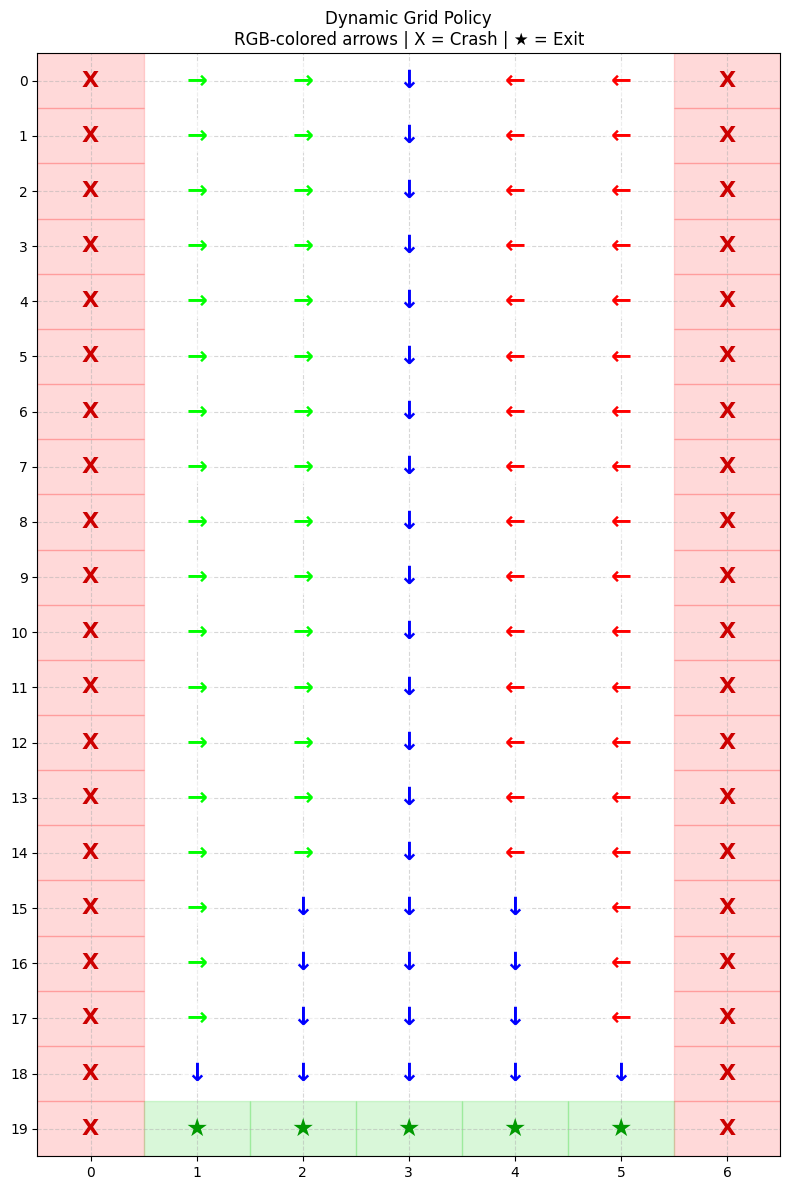

In [1]:
from src.p1.helpers import generate_grid
from src.utils.grid_environment import GridEnvironment
from src.utils.value_convergence import policy_iteration
from src.p1.helpers import visualize_policy
from IPython.display import display
from src.utils.heatmap_animation import show_heatmap_animation_matplotlib

import os
# remove heatmap images
os.system("rm heatmaps/*.png")


# Set parameters for the grid world
grid_size = [20, 7]
reward_range = [-1, -1]
gamma = 0.99
step_penalty = 0
random_transition_type = "m2p1"
random_probability = 0.2 # wind chance
start_state = (0, 3)
range_of_motions = (grid_size[1] - 2) // 5
# action_map = {
#     "forward": (1, 0), 
#     "left": (0, -1), 
#     "right": (0, 1)
# }
action_map = {}

for i in range(range_of_motions):
    action_map["forward_" + str(i+1)] = (i+1, 0)
    action_map["left_" + str(i+1)] = (0, -i-1)
    action_map["right_" + str(i+1)] = (0, i+1)

print(action_map)

# Create the action map

# Create the terminal map
terminal_map = {
    "crash": -20,
    "exit": 100
}

# Generate the grid for the environment
grid = generate_grid(
    grid_size=grid_size,
    reward_range=reward_range,
    terminal_state_values=list(terminal_map.values())
)

print(grid)

# Initialize the environment
chasm_env = GridEnvironment(
    curr_grid=grid,
    terminal_map=terminal_map,
    action_map=action_map,
    gamma=gamma,
    step_penalty=step_penalty,
    random_transition_type=random_transition_type,
    random_probability=random_probability,
    start_state=start_state
)

# Run policy iteration
V, policy = policy_iteration(
    chasm_env,
)

# # Create the animation for the value convergence
# anim = show_heatmap_animation_matplotlib(
#     image_dir="heatmaps",
#     fps=6
# )

# display(anim)

# Print the optimal policy
print("\nOptimal policy:")
for i in range(grid_size[0]):
    for j in range(grid_size[1]):
        if (i, j) in policy:
            print(f"({i},{j}): {policy[(i,j)]}", end="  ")
    print()
print(f"\nTotal states in policy: {len(policy)}")

# Count actions
action_counts = {}
for s, a in policy.items():
    if isinstance(s, tuple):
        action_counts[a] = action_counts.get(a, 0) + 1
print(f"Action distribution: {action_counts}")

# Visualize the policy
visualize_policy(grid_size, policy, mask=grid)



### Problem 2

The state initialization can be seen in the code block below, it assumes a sort of ground truth map to be the inital states. The reward function for this setup is a growing penalty for both being closer to the walls and further from the goal. If i were to do this with a real drone that has known kinematics and sensors, i would likely take the time to build and entire obervation space that would include things like the lidar scan, wheel base information, and encoder readings. Using all of that information i would be able to make a realistic sim to then build a reward structure onto. 

[[   -inf    -inf    -inf    -inf    -inf    -inf    -inf]
 [-120.56    -inf    -inf    -inf    -inf    -inf    -inf]
 [ -72.   -118.56    -inf    -inf    -inf    -inf    -inf]
 [ -22.21  -70.   -116.56    -inf    -inf    -inf    -inf]
 [  -8.    -20.21  -68.   -114.56    -inf    -inf    -inf]
 [  -2.16   -6.    -18.21  -66.   -112.56    -inf    -inf]
 [ 100.    200.    200.    200.    200.    200.      -inf]
 [  -2.16   -6.    -18.21  -66.   -112.56    -inf    -inf]
 [  -8.    -20.21  -68.   -114.56    -inf    -inf    -inf]
 [ -22.21  -70.   -116.56    -inf    -inf    -inf    -inf]
 [ -72.   -118.56    -inf    -inf    -inf    -inf    -inf]
 [-120.56    -inf    -inf    -inf    -inf    -inf    -inf]
 [   -inf    -inf    -inf    -inf    -inf    -inf    -inf]]
P1/P2 Mode - Grid World
S size: 35
A: {'forward', 'left', 'right'}
terminal_states: {'goal', 'crash'}
Policy Iteration: 1
Policy Iteration: 2
Policy Iteration: 3
Policy Iteration: 4
Policy Iteration: 5

Optimal policy:

(1,0): left 

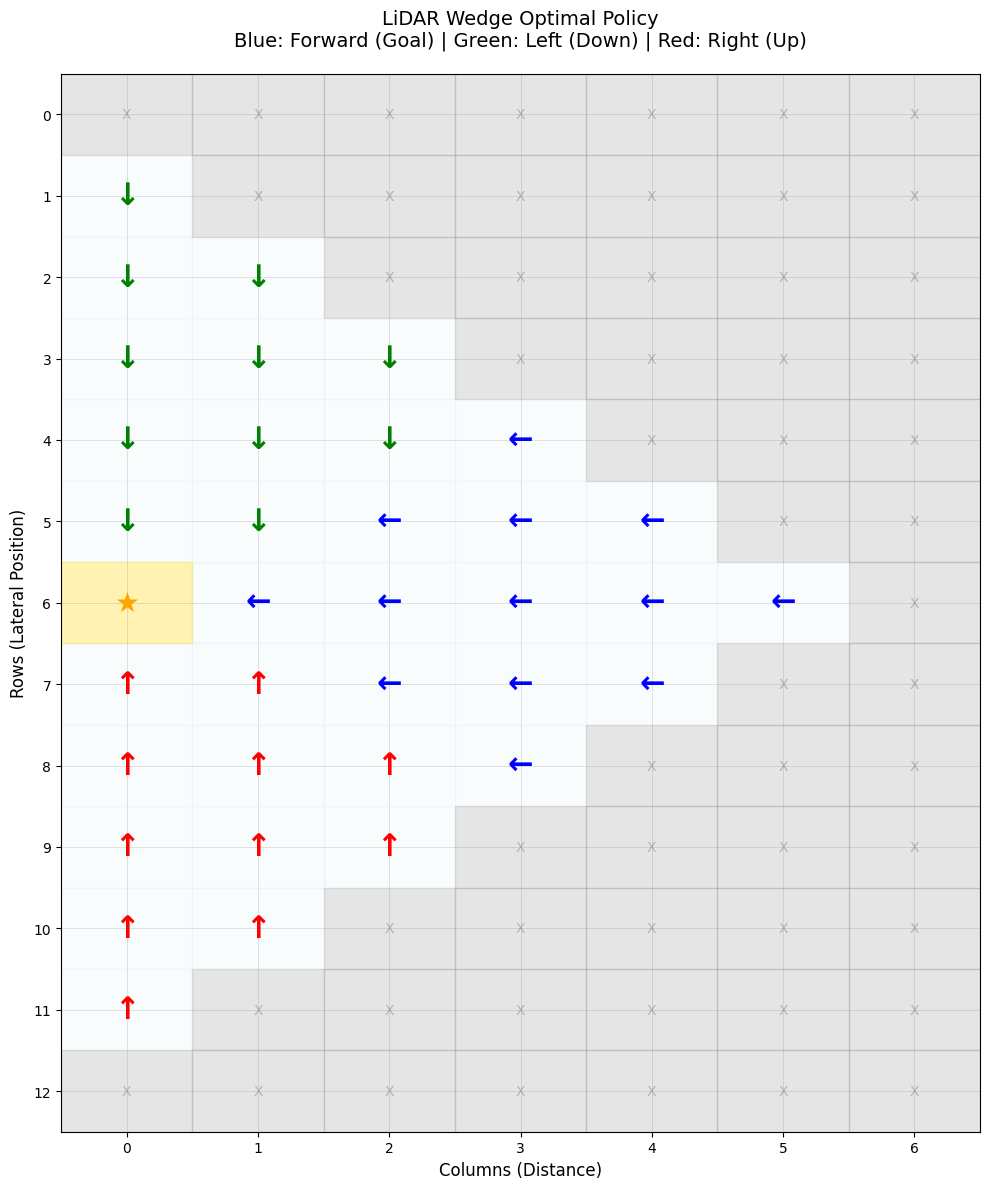

In [2]:
from src.p2.helpers import generate_grid
from src.utils.grid_environment import GridEnvironment
from src.utils.value_convergence import policy_iteration
import numpy as np
from src.p2.helpers import visualize_lidar_policy

LiDAR_range = 6 # range of the LiDAR sensor in meters
grid_size = [(LiDAR_range * 2) + 1, LiDAR_range + 1]
slice_angle = 80 # angle of the LiDAR sensor in degrees
# Create the terminal map
terminal_map = {
    "goal": 100,
    "crash": -10
}

grid = generate_grid(
    grid_size=grid_size,
    terminal_state_values=list(terminal_map.values()),
    slice_angle=slice_angle
)
print(grid)

action_map = {
    "forward": (0, -1), 
    "left": (1, 0), 
    "right": (-1, 0)
}

gamma = 0.99
step_penalty = -1
random_probability = 0.15
start_state = (0, 0)

lidar_env = GridEnvironment(
    curr_grid=grid,
    terminal_map=terminal_map,
    action_map=action_map,
    gamma=gamma,
    step_penalty=step_penalty,
    random_transition_type="m2p2",
    random_probability=random_probability,
    start_state=start_state
)

# Run policy iteration
V, policy = policy_iteration(
    lidar_env,
)

# # Create the animation for the value convergence
# anim = show_heatmap_animation_matplotlib(
#     image_dir="heatmaps",
#     fps=6
# )

# display(anim)

# Print the optimal policy
print("\nOptimal policy:")
for i in range(grid_size[0]):
    for j in range(grid_size[1]):
        if (i, j) in policy:
            print(f"({i},{j}): {policy[(i,j)]}", end="  ")
    print()
print(f"\nTotal states in policy: {len(policy)}")

# Count actions
action_counts = {}
for s, a in policy.items():
    if isinstance(s, tuple):
        action_counts[a] = action_counts.get(a, 0) + 1
print(f"Action distribution: {action_counts}")

visualize_lidar_policy(grid, policy, grid_size)


### Problem 3
To be honest, I struggled for a long time with problem three, I tried many different things and could not get them to work. Eventually I took some time to figure out and prove a best possible solution. From my own work and everything I could find, proofs seemed to determine that the creation of an XOR using only NANDs is not possible without at least 4 NAND gates. Unfortunately this means that the problem is not solvable without more space as there would already be 7 of 9 locations taken leaving no room for the necessary wires. I do have code that attempts to figure it out but it always just returns some random incorrect solution that is not actually a complete circuit.

Given that the issues is space, the first thought would be to just make the grid bigger. However, even with only a 3x3 grid, we have an incredibly large statespace. This is due to the fact that there are 9 possible actions as shown in the action map below. Going to just 4x4 brings S from 6561 to 25509168 with the number just getting exponentially larger as you try to increas the size. 

To make this problem more doable and even more realistic, creating a 3d means of wiring would be necessary. For instance, a real breadboard places gates on a single plane while wires can cross 3 dimensionally above. Creating some sort of environment where action like this are possible would heavily reduce the number of actions per tile while also making the problem solvable in a real world case-secenario.

P3 Mode - Circuit Design
S size: 6561
A: {'remove', 'down', 'up', 'place_nand', 'left', 'right', 'place_wire', 'done'}
terminal_states: 0
Policy Iteration: 1
Policy Iteration: 2
Policy Iteration: 3


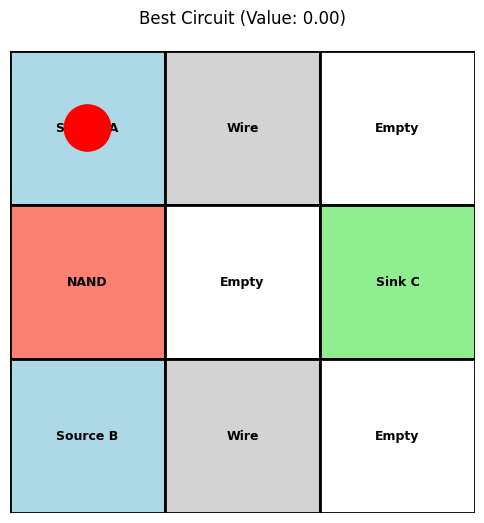

In [3]:
from src.utils.grid_world import gridworld
from src.utils.value_convergence import policy_iteration
from src.p3.helpers import visualize_optimal_circuit

# Your existing gridworld code
S, A, P, r, terminals = gridworld(
    action_map={
        "up": (-1, 0), "down": (1, 0), "left": (0, -1), "right": (0, 1),
        "place_wire": (0, 0), "place_nand": (0, 0), 
        "remove": (0, 0), "done": (0, 0)
    },
    transitions_type="circuit",
    grid_size=3,
    step_penalty=-0,
    correct_reward=100,
    incorrect_penalty=-50
)

# Wrap it
env = GridEnvironment(
    S=S, 
    A=A, 
    P=P, 
    r=r, 
    terminal_states=terminals, 
    gamma=0.99
)

# Solve it
V, policy = policy_iteration(env)
best_state = max(V, key=V.get)
visualize_optimal_circuit(best_state, 
                          title=f"Best Circuit (Value: {V[best_state]:.2f})")